# CICIDS2017 — Multiclass Intrusion Detection (all 8 files)

**What changed vs. the original notebook**

- Original code read `Monday, Tuesday, Wednesday` in order and filled each class quota greedily from
  whichever file it hit first — so `BENIGN` ended up coming almost entirely from Monday, and
  `BRUTEFORCE`/`DOS` from a single file each. Thursday and Friday were never even opened.
- This version:
  1. **Analyzes every file first** (label counts per file) before deciding anything.
  2. Uses **all 8 files** in the dataset (Mon–Fri, including both Thursday and both Friday files).
  3. Groups the many raw attack labels into a smaller set of classes — DoS-type attacks
     (`DoS Hulk`, `DoS GoldenEye`, `DoS slowloris`, `DoS Slowhttptest`, `Heartbleed`, `DDoS`)
     are all merged into one `DOS` class, the same way the original notebook merged the 4 DoS
     variants. Similarly, `FTP-Patator` / `SSH-Patator` / `Web Attack - Brute Force` are merged
     into one `BRUTEFORCE` class. `PortScan`, `Bot`, `Infiltration`, and the remaining Web Attacks
     (XSS / SQL Injection) get their own classes.
  4. **Spreads sampling fairly across every file that contains a class** (a "water-filling"
     quota allocator), so `BENIGN` is pulled from Monday *and* Tuesday *and* ... Friday, not just
     one day.
  5. Does explicit **data-quality analysis**: infinite values, NaNs, exact duplicate rows.
  6. Does a proper **stratified train/test split** and only fits the missing-value imputer on the
     training data (to avoid leaking test-set statistics), instead of testing on a whole separate
     day's file.

**Before running:** update `BASE_DIR` in the next cell to wherever you've put the 8 CICIDS2017 CSVs
(e.g. your Google Drive `MachineLearningCVE` folder from the Kaggle dataset
`chethuhn/network-intrusion-dataset`).

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import re
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option("display.width", 120)
RANDOM_STATE = 42

In [29]:
# ---- point this at the folder that holds all 8 CICIDS2017 CSVs ----
BASE_DIR = "/content/drive/MyDrive/MachineLearningCVE"

FILES = {
    "Monday":            f"{BASE_DIR}/Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday":           f"{BASE_DIR}/Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday":         f"{BASE_DIR}/Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-Morning":  f"{BASE_DIR}/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-Afternoon":f"{BASE_DIR}/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-Morning":    f"{BASE_DIR}/Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-PortScan":   f"{BASE_DIR}/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-DDoS":       f"{BASE_DIR}/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
}

CHUNK_SIZE = 100_000

## Step 1 — Analyze every file first

Read each of the 8 files in chunks (so nothing huge sits in memory) and just count the raw
`Label` values. This is the "first analysis" pass — it tells us what's actually available in
each file before we decide how to sample.

In [30]:
raw_label_counts = {}  # {day: Counter(raw_label -> count)}

for day, path in FILES.items():
    print(f"Scanning {day} ...")
    c = Counter()
    for chunk in pd.read_csv(path, chunksize=CHUNK_SIZE, low_memory=False):
        chunk.columns = chunk.columns.str.strip()
        chunk["Label"] = chunk["Label"].astype(str).str.strip()
        c.update(chunk["Label"].value_counts().to_dict())
    raw_label_counts[day] = c

print("\nDone scanning all files.")

Scanning Monday ...
Scanning Tuesday ...
Scanning Wednesday ...
Scanning Thursday-Morning ...
Scanning Thursday-Afternoon ...
Scanning Friday-Morning ...
Scanning Friday-PortScan ...
Scanning Friday-DDoS ...

Done scanning all files.


In [31]:
# Tidy summary: rows = raw label, columns = day, values = count
summary = pd.DataFrame(raw_label_counts).fillna(0).astype(int)
summary["TOTAL"] = summary.sum(axis=1)
summary = summary.sort_values("TOTAL", ascending=False)
summary

,Monday,Tuesday,Wednesday,Thursday-Morning,Thursday-Afternoon,Friday-Morning,Friday-PortScan,Friday-DDoS,TOTAL
BENIGN,529918,432074,440031,168186,288566,189067,127537,97718,2273097
DoS Hulk,0,0,231073,0,0,0,0,0,231073
PortScan,0,0,0,0,0,0,158930,0,158930
DDoS,0,0,0,0,0,0,0,128027,128027
DoS GoldenEye,0,0,10293,0,0,0,0,0,10293
FTP-Patator,0,7938,0,0,0,0,0,0,7938
SSH-Patator,0,5897,0,0,0,0,0,0,5897
DoS slowloris,0,0,5796,0,0,0,0,0,5796
DoS Slowhttptest,0,0,5499,0,0,0,0,0,5499
Bot,0,0,0,0,0,1966,0,0,1966


## Step 2 — Group raw labels into classes

Same idea as the original notebook's `map_label` (which merged 4 DoS variants into one `DOS`
class) — just extended to all 8 files. Matching is done on a normalized (letters-only,
lowercased) version of the label because some of these CSVs have odd characters in the
`Web Attack` labels (encoding issues with the dash).

In [32]:
# def map_label(raw_label):
#     l = re.sub(r"[^A-Za-z]+", " ", str(raw_label)).strip().lower()

#     if l == "benign":
#         return "BENIGN"

#     # brute-force style attacks (FTP/SSH Patator, and the Thursday web-attack brute force)
#     if "patator" in l or "brute force" in l:
#         return "BRUTEFORCE"

#     # every DoS-style attack (incl. Heartbleed and DDoS) collapses into one DOS class,
#     # same grouping style as the original notebook used for the 4 Wednesday DoS variants
#     if l.startswith("dos") or "heartbleed" in l or "ddos" in l:
#         return "DOS"

#     if "portscan" in l or "port scan" in l:
#         return "PORTSCAN"

#     if l == "bot":
#         return "BOT"

#     if "infiltration" in l:
#         return None

#     if "web attack" in l:
#         return "WEBATTACK"   # XSS / SQL Injection (brute force already handled above)

#     return None  # anything unrecognized is dropped rather than silently mis-labeled

def map_label(raw_label):
    l = re.sub(r"[^A-Za-z]+", " ", str(raw_label)).strip().lower()

    if l == "benign":
        return "BENIGN"

    # protocol-level brute force only (SSH/FTP) — web-layer brute force
    # behaves like an HTTP attack, so it belongs with the other web attacks
    if "patator" in l:                     # <-- removed "or 'brute force' in l"
        return "BRUTEFORCE"

    if l.startswith("dos") or "heartbleed" in l or "ddos" in l:
        return "DOS"

    if "portscan" in l or "port scan" in l:
        return "PORTSCAN"

    if l == "bot":
        return "BOT"

    if "infiltration" in l:
        return None   # ~36 rows total, not enough to model

    if "web attack" in l:
        return "WEBATTACK"   # now includes brute force, XSS, and SQL injection

    return None

# Availability of each *class* per file, derived from the Step-1 counts
availability = {}  # {class: {day: count}}
for day, counter in raw_label_counts.items():
    for raw_label, n in counter.items():
        cls = map_label(raw_label)
        if cls is None:
            continue
        availability.setdefault(cls, {})
        availability[cls][day] = availability[cls].get(day, 0) + n

avail_df = pd.DataFrame(availability).fillna(0).astype(int)
avail_df.loc["TOTAL available"] = avail_df.sum()
avail_df

,BENIGN,BRUTEFORCE,DOS,WEBATTACK,BOT,PORTSCAN
Monday,529918,0,0,0,0,0
Tuesday,432074,13835,0,0,0,0
Wednesday,440031,0,252672,0,0,0
Thursday-Morning,168186,0,0,2180,0,0
Thursday-Afternoon,288566,0,0,0,0,0
Friday-Morning,189067,0,0,0,1966,0
Friday-PortScan,127537,0,0,0,0,158930
Friday-DDoS,97718,0,128027,0,0,0
TOTAL available,2273097,13835,380699,2180,1966,158930


## Step 3 — Decide sample sizes, spread fairly across every day

`TARGET_PER_CLASS` is the *most* rows we'd like per class (auto-capped to whatever actually
exists). `allocate_quotas` then spreads that target as evenly as possible across every file
that contains the class ("water-filling"): every day gets an equal slice first, and only if a
day doesn't have enough rows does its shortfall get redistributed to days that have spare
capacity. This is what fixes "BENIGN only comes from Monday" — BENIGN exists in all 8 files, so
it now gets pulled from all 8.

In [33]:
TARGET_PER_CLASS = {
    "BENIGN":      70_000,
    "BRUTEFORCE":  20_000,
    "DOS":         70_000,
    "PORTSCAN":    40_000,
    "BOT":         10_000,
    "INFILTRATION": 10_000,
    "WEBATTACK":   10_000,
}

def allocate_quotas(target, per_file_availability):
    """Spread `target` rows across the files in per_file_availability as evenly as possible,
    never exceeding what a file actually has, redistributing any shortfall to other files."""
    remaining_target = min(target, sum(per_file_availability.values()))
    quotas = {f: 0 for f in per_file_availability}
    active = set(per_file_availability)
    remaining = remaining_target

    while remaining > 0 and active:
        share = max(1, remaining // len(active))
        progressed = False
        for f in list(active):
            capacity = per_file_availability[f] - quotas[f]
            take = min(share, capacity, remaining)
            if take > 0:
                quotas[f] += take
                remaining -= take
                progressed = True
            if capacity - take <= 0:
                active.discard(f)
            if remaining <= 0:
                break
        if not progressed:
            break
    return quotas


# quotas[day][class] = how many rows of that class to take from that day's file
quotas = {day: {} for day in FILES}
for cls, target in TARGET_PER_CLASS.items():
    if cls not in availability:
        print(f"WARNING: class {cls} not found in any file, skipping")
        continue
    per_file_quota = allocate_quotas(target, availability[cls])
    for day, n in per_file_quota.items():
        if n > 0:
            quotas[day][cls] = n

quota_df = pd.DataFrame(quotas).fillna(0).astype(int)
quota_df["TOTAL"] = quota_df.sum(axis=1)
quota_df.loc["TOTAL"] = quota_df.sum()
quota_df

,Monday,Tuesday,Wednesday,Thursday-Morning,Thursday-Afternoon,Friday-Morning,Friday-PortScan,Friday-DDoS,TOTAL
BENIGN,8750,8750,8750,8750,8750,8750,8750,8750,70000
BRUTEFORCE,0,13835,0,0,0,0,0,0,13835
DOS,0,0,35000,0,0,0,0,35000,70000
WEBATTACK,0,0,0,2180,0,0,0,0,2180
BOT,0,0,0,0,0,1966,0,0,1966
PORTSCAN,0,0,0,0,0,0,40000,0,40000
TOTAL,8750,22585,43750,10930,8750,10716,48750,43750,197981


## Step 4 — Second pass: actually pull the sampled rows

Now that we know exactly how many rows of each class to take from each file, read every file
again in chunks and sample according to the quota table above.

In [34]:
selected = []
remaining = {day: dict(cls_quota) for day, cls_quota in quotas.items()}

for day, path in FILES.items():
    if not remaining[day]:
        continue
    print(f"\nSampling from {day} ...")
    for chunk in pd.read_csv(path, chunksize=CHUNK_SIZE, low_memory=False):
        if not remaining[day]:
            break
        chunk.columns = chunk.columns.str.strip()
        chunk["Label"] = chunk["Label"].astype(str).str.strip()
        chunk["Class"] = chunk["Label"].map(map_label)
        chunk = chunk[chunk["Class"].notna()]

        for cls in list(remaining[day].keys()):
            need = remaining[day][cls]
            if need <= 0:
                del remaining[day][cls]
                continue
            cls_rows = chunk[chunk["Class"] == cls]
            if len(cls_rows) == 0:
                continue
            take_n = min(need, len(cls_rows))
            picked = cls_rows.sample(n=take_n, random_state=RANDOM_STATE)
            selected.append(picked)
            remaining[day][cls] -= take_n

    print(f"  done with {day}, still needed: {remaining[day]}")

final_df = pd.concat(selected, ignore_index=True)
final_df = final_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nFinal class distribution (spread across all days):")
print(final_df["Class"].value_counts())
print("\nShape:", final_df.shape)


Sampling from Monday ...
  done with Monday, still needed: {}

Sampling from Tuesday ...
  done with Tuesday, still needed: {'BRUTEFORCE': 0}

Sampling from Wednesday ...
  done with Wednesday, still needed: {}

Sampling from Thursday-Morning ...
  done with Thursday-Morning, still needed: {}

Sampling from Thursday-Afternoon ...
  done with Thursday-Afternoon, still needed: {}

Sampling from Friday-Morning ...
  done with Friday-Morning, still needed: {'BOT': 0}

Sampling from Friday-PortScan ...
  done with Friday-PortScan, still needed: {}

Sampling from Friday-DDoS ...
  done with Friday-DDoS, still needed: {}

Final class distribution (spread across all days):
Class
DOS           70000
BENIGN        70000
PORTSCAN      40000
BRUTEFORCE    13835
WEBATTACK      2180
BOT            1966
Name: count, dtype: int64

Shape: (197981, 80)


In [35]:
output_path = f"{BASE_DIR}/multiclass_dataset_all_days.csv"
final_df.to_csv(output_path, index=False)
print("Saved combined (uncleaned) dataset to:", output_path)

Saved combined (uncleaned) dataset to: /content/drive/MyDrive/MachineLearningCVE/multiclass_dataset_all_days.csv


## Step 5 — Data-quality analysis and cleaning

Check for infinite values, missing values, and exact duplicate rows before doing anything else
with this data.

In [36]:
print("Shape before cleaning:", final_df.shape)

numeric_cols = final_df.select_dtypes(include=[np.number]).columns

inf_counts = np.isinf(final_df[numeric_cols]).sum()
inf_counts = inf_counts[inf_counts > 0]
print("\nColumns with infinite values:")
print(inf_counts if len(inf_counts) else "  none")

nan_counts = final_df.isna().sum()
nan_counts = nan_counts[nan_counts > 0]
print("\nColumns with NaN values (before replacing infinities):")
print(nan_counts if len(nan_counts) else "  none")

dup_count = final_df.duplicated().sum()
print(f"\nExact duplicate rows: {dup_count}")

Shape before cleaning: (197981, 80)

Columns with infinite values:
Flow Bytes/s       79
Flow Packets/s    161
dtype: int64

Columns with NaN values (before replacing infinities):
Flow Bytes/s    82
dtype: int64

Exact duplicate rows: 17354


In [37]:
# 1) drop exact duplicate rows
final_df = final_df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", final_df.shape)

# 2) infinities -> NaN (they'll be imputed after the train/test split, see Step 6,
#    so that the fill values are learned only from the training data)
final_df[numeric_cols] = final_df[numeric_cols].replace([np.inf, -np.inf], np.nan)

nan_counts_after = final_df.isna().sum()
nan_counts_after = nan_counts_after[nan_counts_after > 0]
print("\nColumns with NaN after inf->NaN conversion (to be imputed next step):")
print(nan_counts_after if len(nan_counts_after) else "  none")

Shape after dropping duplicates: (180627, 80)

Columns with NaN after inf->NaN conversion (to be imputed next step):
Flow Bytes/s      87
Flow Packets/s    87
dtype: int64


## Step 6 — Train/test split (held out *before* imputation)

We split first and only compute the median fill-values from the **training** split, then apply
those same values to the test split. This avoids leaking any information from the held-out test
rows into training — testing on a fully separate day's file (like the original notebook did)
is a good extra sanity check, but a random stratified split is what actually gives you an
honest, class-balanced estimate of generalization.

In [38]:
X = final_df.drop(columns=["Class", "Label"])
y = final_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# fit the imputer (median) on the TRAIN split only
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

Train shape: (144501, 78)  Test shape: (36126, 78)

Train class distribution:
 Class
BENIGN        55213
DOS           52684
PORTSCAN      26006
BRUTEFORCE     7322
WEBATTACK      1714
BOT            1562
Name: count, dtype: int64

Test class distribution:
 Class
BENIGN        13804
DOS           13171
PORTSCAN       6501
BRUTEFORCE     1830
WEBATTACK       429
BOT             391
Name: count, dtype: int64


## Step 7 — Train the model

In [39]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced",
)
rf.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Step 8 — Evaluate on the held-out test set

In [40]:
y_pred = rf.predict(X_test)

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix (rows=actual, cols=predicted):")
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
print(pd.DataFrame(cm, index=sorted(y.unique()), columns=sorted(y.unique())))

TEST SET RESULTS

Accuracy: 99.72%

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     13804
         BOT       0.95      0.97      0.96       391
  BRUTEFORCE       1.00      1.00      1.00      1830
         DOS       1.00      1.00      1.00     13171
    PORTSCAN       1.00      1.00      1.00      6501
   WEBATTACK       0.99      0.98      0.99       429

    accuracy                           1.00     36126
   macro avg       0.99      0.99      0.99     36126
weighted avg       1.00      1.00      1.00     36126


Confusion Matrix (rows=actual, cols=predicted):
            BENIGN  BOT  BRUTEFORCE    DOS  PORTSCAN  WEBATTACK
BENIGN       13753   21           1      4        25          0
BOT             10  381           0      0         0          0
BRUTEFORCE       1    0        1829      0         0          0
DOS             18    0           0  13153         0          0
PORTSCAN        11    0      

In [41]:
# ── Check for Destination Port leakage ──────────────────────────────
# Same split, same model settings, just drop Destination Port and
# retrain, so any accuracy drop is attributable to that feature alone.

X_train_noport = X_train.drop(columns=["Destination Port"])
X_test_noport  = X_test.drop(columns=["Destination Port"])

rf_noport = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_noport.fit(X_train_noport, y_train)

y_pred_noport = rf_noport.predict(X_test_noport)

print("=" * 60)
print("TEST SET RESULTS — WITHOUT Destination Port")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_noport):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_noport))
print("\nConfusion Matrix (rows=actual, cols=predicted):")
cm_noport = confusion_matrix(y_test, y_pred_noport, labels=sorted(y.unique()))
print(pd.DataFrame(cm_noport, index=sorted(y.unique()), columns=sorted(y.unique())))

TEST SET RESULTS — WITHOUT Destination Port

Accuracy: 99.65%

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     13804
         BOT       0.94      0.96      0.95       391
  BRUTEFORCE       1.00      1.00      1.00      1830
         DOS       1.00      1.00      1.00     13171
    PORTSCAN       1.00      1.00      1.00      6501
   WEBATTACK       0.99      0.96      0.98       429

    accuracy                           1.00     36126
   macro avg       0.99      0.99      0.99     36126
weighted avg       1.00      1.00      1.00     36126


Confusion Matrix (rows=actual, cols=predicted):
            BENIGN  BOT  BRUTEFORCE    DOS  PORTSCAN  WEBATTACK
BENIGN       13742   24           2     10        25          1
BOT             14  376           0      1         0          0
BRUTEFORCE       9    0        1821      0         0          0
DOS             20    1           0  13150         0          0
PO

In [42]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report

le = LabelEncoder().fit(y_train)
ytr, yte = le.transform(y_train), le.transform(y_test)
xgb = XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, tree_method="hist", n_jobs=-1, random_state=42)
xgb.fit(X_train, ytr, sample_weight=compute_sample_weight("balanced", ytr))
print(classification_report(yte, xgb.predict(X_test), target_names=le.classes_, digits=4))

              precision    recall  f1-score   support

      BENIGN     0.9995    0.9965    0.9980     13804
         BOT     0.9465    0.9949    0.9701       391
  BRUTEFORCE     0.9995    1.0000    0.9997      1830
         DOS     0.9998    0.9995    0.9997     13171
    PORTSCAN     0.9962    0.9995    0.9979      6501
   WEBATTACK     0.9907    0.9977    0.9942       429

    accuracy                         0.9983     36126
   macro avg     0.9887    0.9980    0.9933     36126
weighted avg     0.9983    0.9983    0.9983     36126



In [47]:
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

for name, m in {
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=42, verbose=-1),
}.items():
    m.fit(X_train, ytr)
    print(f"\n=== {name} ===")
    print(classification_report(yte, m.predict(X_test), target_names=le.classes_, digits=4))


=== DecisionTree ===
              precision    recall  f1-score   support

      BENIGN     0.9972    0.9948    0.9960     13804
         BOT     0.9424    0.9616    0.9519       391
  BRUTEFORCE     0.9995    0.9989    0.9992      1830
         DOS     0.9989    0.9993    0.9991     13171
    PORTSCAN     0.9952    0.9975    0.9964      6501
   WEBATTACK     0.9725    0.9883    0.9803       429

    accuracy                         0.9967     36126
   macro avg     0.9843    0.9901    0.9872     36126
weighted avg     0.9967    0.9967    0.9967     36126


=== LightGBM ===
              precision    recall  f1-score   support

      BENIGN     0.9987    0.9967    0.9977     13804
         BOT     0.9524    0.9719    0.9620       391
  BRUTEFORCE     1.0000    1.0000    1.0000      1830
         DOS     0.9998    0.9995    0.9997     13171
    PORTSCAN     0.9963    0.9994    0.9978      6501
   WEBATTACK     0.9930    0.9977    0.9953       429

    accuracy                         

In [ ]:
# quick feature-importance sanity check
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15)

In [ ]:
# ── SMOTE: oversample minority classes on the TRAINING set only ────────────
# Important: SMOTE must be applied AFTER the train/test split, and only to
# the training data — same leakage principle as the median imputation.
# If we SMOTE'd before splitting, synthetic rows built from a real test-set
# row's neighbors could end up back in the test set, or synthetic rows near
# test rows could leak information about them into training.
#
# !pip install imbalanced-learn   # run once if not already installed

from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train_sm.value_counts())

In [ ]:
rf_smote1 = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_smote1.fit(X_train_sm, y_train_sm)
print("Model trained on SMOTE-resampled data.")

y_pred_sm = rf_smote1.predict(X_test)
print("=" * 60)
print("SMOTE + RANDOMFOREST — TEST SET RESULTS")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_sm):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sm))
print("\nConfusion Matrix (rows=actual, cols=predicted):")
cm_sm = confusion_matrix(y_test, y_pred_sm, labels=sorted(y.unique()))
print(pd.DataFrame(cm_sm, index=sorted(y.unique()), columns=sorted(y.unique())))

In [21]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=RANDOM_STATE)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)

print("Before SMOTETomek:")
print(y_train.value_counts())
print("\nAfter SMOTETomek:")
print(y_train_smt.value_counts())



Before SMOTETomek:
Class
BENIGN        55213
DOS           52684
PORTSCAN      26006
BRUTEFORCE     7322
WEBATTACK      1714
BOT            1562
Name: count, dtype: int64

After SMOTETomek:
Class
BOT           55187
WEBATTACK     55183
BRUTEFORCE    55174
PORTSCAN      55171
DOS           55132
BENIGN        55039
Name: count, dtype: int64


In [22]:
rf_smt = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_smt.fit(X_train_smt, y_train_smt)
print("\nModel trained on SMOTETomek-resampled data.")

y_pred_smt = rf_smt.predict(X_test)

print("=" * 60)
print("SMOTETOMEK + RANDOMFOREST — TEST SET RESULTS")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_smt):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smt))
print("\nConfusion Matrix (rows=actual, cols=predicted):")
cm_smt = confusion_matrix(y_test, y_pred_smt, labels=sorted(y.unique()))
print(pd.DataFrame(cm_smt, index=sorted(y.unique()), columns=sorted(y.unique())))


Model trained on SMOTETomek-resampled data.
SMOTETOMEK + RANDOMFOREST — TEST SET RESULTS

Accuracy: 99.72%

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     13804
         BOT       0.92      0.98      0.95       391
  BRUTEFORCE       1.00      1.00      1.00      1830
         DOS       1.00      1.00      1.00     13171
    PORTSCAN       1.00      1.00      1.00      6501
   WEBATTACK       0.99      1.00      0.99       429

    accuracy                           1.00     36126
   macro avg       0.98      0.99      0.99     36126
weighted avg       1.00      1.00      1.00     36126


Confusion Matrix (rows=actual, cols=predicted):
            BENIGN  BOT  BRUTEFORCE    DOS  PORTSCAN  WEBATTACK
BENIGN       13742   31           1      4        25          1
BOT              9  382           0      0         0          0
BRUTEFORCE       1    0        1829      0         0          0
DOS             16  

In [ ]:
# ── Visualize class overlap using PCA ───────────────────────────────────────
# Compresses all features into 2 dimensions so we can actually see whether
# WEBATTACK and BRUTEFORCE occupy the same region of feature space, or are
# genuinely separable and the model is just struggling for other reasons.

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale first — PCA is sensitive to feature scale, and our features
# (byte counts, durations, port numbers) are on very different scales.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_scaled)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

# Build a small dataframe for easy filtering/plotting
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Class"] = y_train.values

# Focus on the two classes we're investigating, plus BENIGN as a reference
# point for "what a cleanly-separated class looks like"
classes_to_plot = ["BENIGN", "BRUTEFORCE", "WEBATTACK"]
colors = {"BENIGN": "lightgray", "BRUTEFORCE": "tab:blue", "WEBATTACK": "tab:red"}

plt.figure(figsize=(12, 10))
for cls in classes_to_plot:
    subset = pca_df[pca_df["Class"] == cls]
    plt.scatter(
        subset["PC1"], subset["PC2"],
        s=10, alpha=0.5,
        label=f"{cls} (n={len(subset)})",
        color=colors[cls],
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection: BRUTEFORCE vs WEBATTACK vs BENIGN")
plt.legend()
plt.tight_layout()
plt.show()

## Notes / knobs to revisit

- `TARGET_PER_CLASS` — raise/lower per-class sample sizes; anything above what's actually
  available is auto-capped by `allocate_quotas`.
- `map_label` merges DoS + DDoS + Heartbleed into one `DOS` class and all brute-force-style
  attacks into one `BRUTEFORCE` class, matching the original notebook's grouping style. Split
  `DDoS` back out into its own class if you want DoS vs. DDoS distinguished.
- Rare classes (`BOT`, `INFILTRATION`, `WEBATTACK`) have very few rows in the raw dataset
  (Infiltration in particular is only a few dozen rows total) — check the Step-1/Step-2 tables
  before trusting their precision/recall numbers, and consider whether they belong in a
  3-class model instead once you've seen the real counts.

## Step 4b — Alternative sampling: proportional spread across the whole file

**This is kept separate from Step 4 above on purpose** — the original `final_df` /
`X_train` / `y_train` / `y_test` (and every result built on them: baseline RF, `class_weight`,
SMOTE, SMOTETomek, PCA) are left untouched so they can still be compared against this version.

**Why this exists:** Step 4's sampling reads a file chunk by chunk (`CHUNK_SIZE = 100_000`
rows at a time) and fills each class's quota from whichever chunks it reaches first, then stops
once the quota is full. If a class's rows happen to be concentrated early in a file, later chunks
(later time periods in that day's capture) never get sampled from at all for that class — the
randomness is local to each chunk, but which *chunks* get used is not evenly spread across the file.

**What this version does differently:** for every chunk, it takes a *share* of each class's
remaining quota proportional to that chunk's share of the class's remaining rows in the file
(both tracked using the exact per-file totals already computed in Step 1's `availability` table).
This makes the sample spread evenly across the entire file from start to end, instead of being
front-loaded into the first chunks read.

Produces `final_df_uniform` (does not overwrite `final_df`).

In [24]:
# ── Step 4b — proportional sampling spread across the WHOLE file ───────────
# For every chunk, take a share of each class's remaining quota proportional
# to that chunk's share of the class's remaining rows in the file, using the
# exact per-file totals from Step 1's `availability` table. This spreads the
# sample evenly across the entire file instead of front-loading it into the
# first chunks encountered (which is what Step 4 above does).

selected_uniform = []

for day, path in FILES.items():
    day_quota = quotas[day]
    if not day_quota:
        continue

    print(f"\nSampling from {day} (proportional) ...")

    # what's left to find, and how much of each class is left to see —
    # both start at the full known totals from Step 1
    remaining_quota = dict(day_quota)
    remaining_available = {cls: availability[cls][day] for cls in day_quota}

    for chunk in pd.read_csv(path, chunksize=CHUNK_SIZE, low_memory=False):
        chunk.columns = chunk.columns.str.strip()
        chunk["Label"] = chunk["Label"].astype(str).str.strip()
        chunk["Class"] = chunk["Label"].map(map_label)
        chunk = chunk[chunk["Class"].notna()]

        for cls in list(remaining_quota.keys()):
            if remaining_quota[cls] <= 0:
                continue

            cls_rows = chunk[chunk["Class"] == cls]
            n_in_chunk = len(cls_rows)
            if n_in_chunk == 0:
                continue

            # this chunk's fair share of what's still owed for this class
            if remaining_available[cls] > 0:
                take_n = round(remaining_quota[cls] * n_in_chunk / remaining_available[cls])
            else:
                take_n = 0
            take_n = min(take_n, n_in_chunk, remaining_quota[cls])

            if take_n > 0:
                picked = cls_rows.sample(n=take_n, random_state=RANDOM_STATE)
                selected_uniform.append(picked)
                remaining_quota[cls] -= take_n

            remaining_available[cls] -= n_in_chunk

    left = {k: v for k, v in remaining_quota.items() if v > 0}
    print(f"  done with {day}, still needed: {left}")

final_df_uniform = pd.concat(selected_uniform, ignore_index=True)
final_df_uniform = final_df_uniform.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nFinal class distribution (proportional spread across all days):")
print(final_df_uniform["Class"].value_counts())
print("\nShape:", final_df_uniform.shape)



Sampling from Monday (proportional) ...
  done with Monday, still needed: {}

Sampling from Tuesday (proportional) ...
  done with Tuesday, still needed: {}

Sampling from Wednesday (proportional) ...
  done with Wednesday, still needed: {}

Sampling from Thursday-Morning (proportional) ...
  done with Thursday-Morning, still needed: {}

Sampling from Thursday-Afternoon (proportional) ...
  done with Thursday-Afternoon, still needed: {}

Sampling from Friday-Morning (proportional) ...
  done with Friday-Morning, still needed: {}

Sampling from Friday-PortScan (proportional) ...
  done with Friday-PortScan, still needed: {}

Sampling from Friday-DDoS (proportional) ...
  done with Friday-DDoS, still needed: {}

Final class distribution (proportional spread across all days):
Class
DOS           70000
BENIGN        70000
PORTSCAN      40000
BRUTEFORCE    13835
WEBATTACK      2180
BOT            1966
Name: count, dtype: int64

Shape: (197981, 80)


In [ ]:
# ── Quick comparison: Step 4 (greedy) vs Step 4b (proportional) ────────────
# Same target quotas, same files — this just checks whether the two sampling
# strategies pulled noticeably different class totals (they shouldn't differ by
# much in TOTAL count, since both are capped by the same TARGET_PER_CLASS; the
# real difference is *where within each file* the rows came from, which isn't
# visible from counts alone but affects how representative the sample is of
# the full time range of each capture).

compare_counts = pd.DataFrame({
    "Step4_greedy": final_df["Class"].value_counts(),
    "Step4b_proportional": final_df_uniform["Class"].value_counts(),
})
compare_counts["diff"] = compare_counts["Step4b_proportional"] - compare_counts["Step4_greedy"]
compare_counts


Total BRUTEFORCE rows found: 13835
Total rows in Tuesday's file: 445909


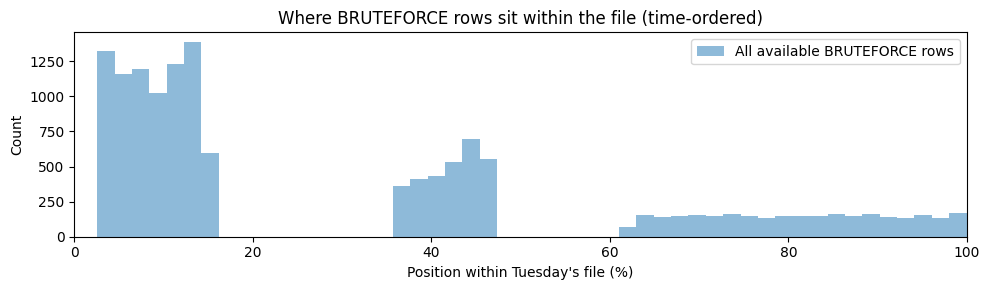

In [26]:
# ── Check WHERE in each file the samples came from (row position as % through file) ──
# This is what value_counts() can't show — same totals, different time coverage.

import matplotlib.pyplot as plt

# reload just the Label column with original row position, per file, for one class to compare
# (BRUTEFORCE is a good test case — concentrated in Tuesday's file, and a mid-size class)

def row_positions_for_class(path, target_class, chunk_size=100_000):
    positions = []
    for chunk in pd.read_csv(path, chunksize=chunk_size, low_memory=False):
        chunk.columns = chunk.columns.str.strip()
        chunk["Label"] = chunk["Label"].astype(str).str.strip()
        chunk["Class"] = chunk["Label"].map(map_label)
        # chunk.index already reflects true position in the whole file
        # (pandas does NOT reset the index to 0 for each chunk), so no
        # manual offset is needed here.
        match_idx = chunk.index[chunk["Class"] == target_class]
        positions.extend(match_idx.tolist())
    return positions

all_positions = row_positions_for_class(FILES["Tuesday"], "BRUTEFORCE")
total_rows = sum(1 for _ in open(FILES["Tuesday"])) - 1  # minus header row
all_positions_pct = [p / total_rows * 100 for p in all_positions]

print(f"Total BRUTEFORCE rows found: {len(all_positions)}")
print(f"Total rows in Tuesday's file: {total_rows}")

plt.figure(figsize=(10, 3))
plt.hist(all_positions_pct, bins=50, alpha=0.5, label="All available BRUTEFORCE rows")
plt.xlabel("Position within Tuesday's file (%)")
plt.ylabel("Count")
plt.title("Where BRUTEFORCE rows sit within the file (time-ordered)")
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

**To actually train/evaluate on this version:** repeat Steps 5–8 using `final_df_uniform` in
place of `final_df` (data-quality cleaning → train/test split → fit imputer on train only → train
RandomForest → evaluate). Kept as a separate exercise here rather than duplicated automatically,
so you can choose whether to run it as a full parallel pipeline or just inspect the row counts above
first.